## Задание
Продолжаем работать с объединенным датасетом merged_data

**Задача 1** 

Цель: выделить пользователей, которые делают упор на индивидуальные тренировки.

Что сделать:
Выберите пользователей, у которых >70% тренировок — индивидуальные.
Для этих пользователей:
+ Посчитайте средний чек;
+ Посчитайте среднее число тренировок в месяц;
+ Разбейте их по городам и полу.

Вопросы для анализа:

+ Кто чаще выбирает индивидуальные тренировки?
+ Есть ли зависимость от пола или города?
+ Насколько высок средний чек у таких пользователей?

**Задача 2.**
Найдите 10 пользователей с наибольшим общим количеством посещений (групповые + индивидуальные тренировки) за весь период наблюдения.

Что нужно сделать:

+ Рассчитайте общее количество тренировок для каждого пользователя.

+ Определите 10 самых активных пользователей и сохраните их идентификаторы в виде списка.

Постройте распределение этих пользователей по:

+ городу
+ полу

Вопросы для анализа:
+ В каких городах больше всего супер-активных клиентов?
+ Какого они пола?

**Задача 3** 
Ваша цель — проанализировать, как менялась клиентская база по месяцам:
сколько клиентов приходило, сколько уходило и сколько оставалось активными.

Шаги:
+ Новые клиенты — это те, у кого первый месяц появления (минимальный mon в данных).

+ Ушедшие клиенты — это те, у кого последний месяц активности (максимальный mon в данных).

+ Активные клиенты — это те, кто был активен в конкретном месяце.

Что нужно сделать:
Рассчитайте три метрики для каждого месяца:
+ new_clients: количество клиентов, для которых этот месяц — первый.
+ gone_clients: количество клиентов, для которых этот месяц — последний.
+ active_clients: общее количество уникальных клиентов в этом месяце.

Для этого:
Создайте три отдельных датафрейма:

+ с новыми клиентами по месяцам,
+ с ушедшими клиентами по месяцам,
+ с активными клиентами по месяцам.

Объедините их по полю mon.

Постройте линейный график с тремя линиями.

Подсказка:
+ Используйте groupby и nunique() для подсчёта количества клиентов.
+ Для объединения датафреймов — merge.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head(3)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female


### Задача 1. Пользователи с 70%+ инд.тренировок

In [3]:
user_totals = df.groupby(['id_user', 'city', 'gender']).agg({'cnt_indiv':'sum'
                                                             ,'cnt_total': 'sum'
                                                            ,'sum_indiv': 'sum'
                                                             ,'mon': 'nunique'
                                                            }).reset_index()
user_totals.head(3)

,id_user,city,gender,cnt_indiv,cnt_total,sum_indiv,mon
0,1000,СПб,female,33,33,58600,9
1,1001,Москва,female,23,129,40000,11
2,1002,Москва,male,64,128,113200,11


In [4]:
# Выделить пользователей, которые делают упор на индивидуальные тренировки.
user_totals['overall_share_indiv'] = user_totals['cnt_indiv'] / user_totals['cnt_total']
user_totals.head(3)

,id_user,city,gender,cnt_indiv,cnt_total,sum_indiv,mon,overall_share_indiv
0,1000,СПб,female,33,33,58600,9,1.000000
1,1001,Москва,female,23,129,40000,11,0.178295
2,1002,Москва,male,64,128,113200,11,0.500000


In [5]:
# Что сделать: Выберите пользователей, у которых >70% тренировок — индивидуальные.
target_users = user_totals.loc[user_totals['overall_share_indiv'] > 0.7].copy()
target_users.head(3)

,id_user,city,gender,cnt_indiv,cnt_total,sum_indiv,mon,overall_share_indiv
0,1000,СПб,female,33,33,58600,9,1.0
3,1004,Екатеринбург,male,18,18,32000,9,1.0
4,1005,СПб,female,7,7,12600,2,1.0


In [6]:
target_users['avg_check_per_month'] = target_users['sum_indiv'] / target_users['mon']
target_users['avg_cnt_per_month'] = target_users['cnt_indiv'] / target_users['mon']
target_users.head()

,id_user,city,gender,cnt_indiv,cnt_total,sum_indiv,mon,overall_share_indiv,avg_check_per_month,avg_cnt_per_month
0,1000,СПб,female,33,33,58600,9,1.0,6511.111111,3.666667
3,1004,Екатеринбург,male,18,18,32000,9,1.0,3555.555556,2.000000
4,1005,СПб,female,7,7,12600,2,1.0,6300.000000,3.500000
6,1007,Москва,female,5,5,9000,4,1.0,2250.000000,1.250000
8,1009,Москва,female,9,9,16200,4,1.0,4050.000000,2.250000


In [7]:
final_city_gender_report = target_users.groupby(['city', 'gender']).agg({'avg_check_per_month': 'mean'
                                                                         ,'avg_cnt_per_month': 'mean'
                                                                         ,'id_user': 'nunique'}).reset_index()\
                                                                                               .rename(columns={'avg_check_per_month': 'avg_check'
                                                                                                               ,'avg_cnt_per_month': 'avg_cnt_trains'
                                                                                                               ,'id_user': 'cnt_users'}).round(2)
final_city_gender_report

,city,gender,avg_check,avg_cnt_trains,cnt_users
0,Екатеринбург,female,5391.75,3.01,12
1,Екатеринбург,male,5832.39,3.26,12
2,Казань,female,6022.50,3.41,8
3,Казань,male,5229.38,2.93,12
4,Москва,female,5558.65,3.13,118
5,Москва,male,6915.32,3.87,59
6,СПб,female,6093.28,3.40,32
7,СПб,male,5024.89,2.82,28


### Задача 2. Топ-10 клиентов

In [8]:
#Найдите 10 пользователей с наибольшим общим количеством посещений (групповые + индивидуальные тренировки) за весь период наблюдения.
#Рассчитайте общее количество тренировок для каждого пользователя.

top10_users = df.groupby('id_user')['cnt_total'].sum().reset_index() \
                                                .sort_values('cnt_total', ascending = False).head(10)
top10_users

,id_user,cnt_total
319,1381,159
12,1013,151
551,1657,144
420,1506,138
780,1929,130
474,1570,129
1,1001,129
2,1002,128
168,1194,127
485,1582,127


In [9]:
#Определите 10 самых активных пользователей и сохраните их идентификаторы в виде списка.
lst_top10 = top10_users['id_user'].tolist()
lst_top10

[1381, 1013, 1657, 1506, 1929, 1570, 1001, 1002, 1194, 1582]

In [10]:
df_top10 = df.loc[df['id_user'].isin(lst_top10)]
df_top10.head(2)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female
10,1001,2023-02,11,3,8800,5400,14,14200,2023-01,2023-12,Москва,35.0,female


In [11]:
#Постройте распределение этих пользователей по: городу, полу
df_top10_gr = df_top10.groupby(['city', 'gender']).agg({'id_user' : 'nunique'
                                                       ,'cnt_total': 'sum'
                                                       ,'mon' : 'count'}).reset_index() \
                                                                         . rename(columns = {'id_user' : 'cnt_users'
                                                                                               ,'cnt_total' : 'cnt_trains'
                                                                                               ,'mon' : 'cnt_month'})
                                                                                                  
df_top10_gr

,city,gender,cnt_users,cnt_trains,cnt_month
0,Екатеринбург,male,2,256,19
1,Москва,female,3,426,33
2,Москва,male,3,409,33
3,СПб,female,1,127,12
4,СПб,male,1,144,10


### Задача 3. Динамика клиентской базы

In [12]:
#new_clients: количество клиентов, для которых этот месяц — первый.

new_clients = df.groupby('min_mon').agg(cnt_new_users = ('id_user',  'nunique')).reset_index() \
                                                                                .rename(columns = ({'min_mon' : 'mon'}))
new_clients.head(3)

,mon,cnt_new_users
0,2023-01,337
1,2023-02,88
2,2023-03,83


In [13]:
#gone_clients: количество клиентов, для которых этот месяц — последний.

gone_clients = df.groupby('max_mon').agg(cnt_gone_users = ('id_user',  'nunique')).reset_index() \
                                                                                  .rename(columns = ({'max_mon' : 'mon'}))
gone_clients.head(3)

,mon,cnt_gone_users
0,2023-01,15
1,2023-02,22
2,2023-03,37


In [14]:
#active_clients: общее количество уникальных клиентов в этом месяце.

active_clients = df.groupby('mon').agg(cnt_active_clients = ('id_user',  'nunique')).reset_index()
active_clients.head(3)

,mon,cnt_active_clients
0,2023-01,337
1,2023-02,350
2,2023-03,355


In [15]:
#Объедините их по полю mon.
merged_table = new_clients.merge(gone_clients, on = 'mon', how = 'inner').merge(active_clients, on = 'mon', how = 'inner')
merged_table

,mon,cnt_new_users,cnt_gone_users,cnt_active_clients
0,2023-01,337,15,337
1,2023-02,88,22,350
2,2023-03,83,37,355
3,2023-04,62,21,345
4,2023-05,57,21,360
5,2023-06,51,13,383
6,2023-07,48,33,412
7,2023-08,35,33,423
8,2023-09,28,55,429
9,2023-10,27,101,441


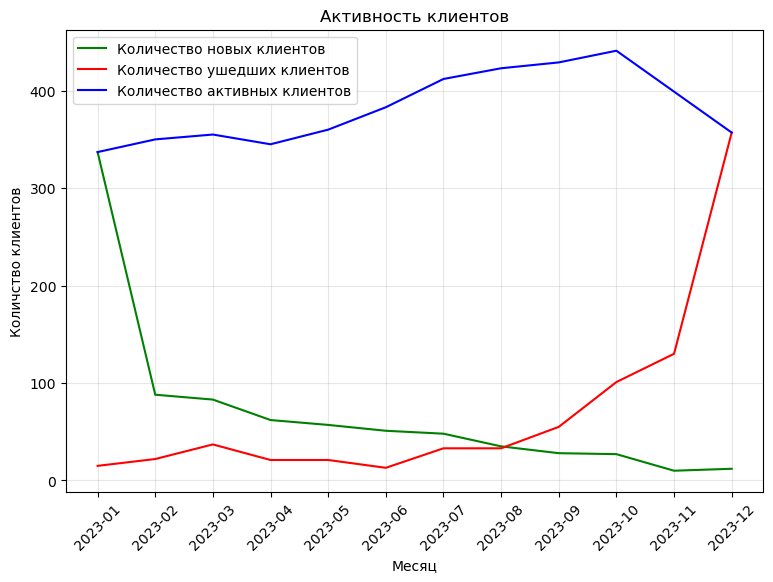

In [16]:
fig, ax = plt.subplots(figsize = (9, 6))

ax.plot(merged_table.iloc[:, 0], merged_table.iloc[:, 1],'g', label = 'Количество новых клиентов')
ax.plot(merged_table.iloc[:, 0], merged_table.iloc[:, 2],'r', label = 'Количество ушедших клиентов')
ax.plot(merged_table.iloc[:, 0], merged_table.iloc[:, 3],'b', label = 'Количество активных клиентов')

ax.set_title('Активность клиентов')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количство клиентов')

ax.grid(alpha = 0.3)
ax.legend()
ax.xaxis.set_tick_params(rotation = 45)
plt.savefig('Активность клиентов.png', dpi = 300, bbox_inches = 'tight', transparent = True)
plt.show()